# Comments


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [49]:
import json
posts = []
with open('../data/raw/posts.json') as f:
    posts = json.loads(f.read())
posts[:1][0]['url']

'https://www.facebook.com/groups/980298767865372/permalink/1047122047849710/'

In [55]:
df = pd.DataFrame(posts)
df.head(2)

,facebookUrl,url,time,user,collaborators,text,topReactionsCount,feedbackId,reactionLoveCount,paidPartnership,...,previewTitle,previewDescription,previewSource,previewTarget,title,videoPostViewCount,reactionSadCount,musicInfo,actionLink,reactionAngryCount
0,https://www.facebook.com/groups/98029876786537...,https://www.facebook.com/groups/98029876786537...,2026-07-23T02:53:10.000Z,{'id': 'pfbid0PtVRMUELMhjQMPjQT5uwh4iLwabDJyLA...,[],"Hello, do you guys recommend Google AI Studio?",1,ZmVlZGJhY2s6MTA0NzEyMjA0Nzg0OTcxMA==,2.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.facebook.com/groups/98029876786537...,https://www.facebook.com/groups/98029876786537...,2026-07-22T14:13:34.000Z,"{'id': '100077493259877', 'name': 'Rom Eugenio...",[],Hello! First time posting here! Medyo mainit n...,4,ZmVlZGJhY2s6MTA0NjcwNDI3Nzg5MTQ4Nw==,20.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
df['time'] = pd.to_datetime(df['time'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1916 entries, 0 to 1915
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   facebookUrl         1916 non-null   str                
 1   url                 1916 non-null   str                
 2   time                1916 non-null   datetime64[us, UTC]
 3   user                1916 non-null   object             
 4   collaborators       1916 non-null   object             
 5   text                1916 non-null   str                
 6   topReactionsCount   1916 non-null   int64              
 7   feedbackId          1916 non-null   str                
 8   reactionLoveCount   1339 non-null   float64            
 9   paidPartnership     1916 non-null   bool               
 10  topComments         1283 non-null   object             
 11  id                  1916 non-null   str                
 12  legacyId            1916 non-null   str      

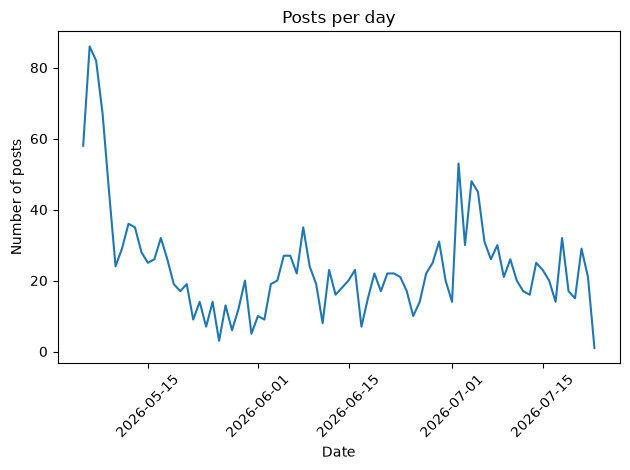

In [52]:
df['time'].dt.date.value_counts().sort_index().plot(kind='line', rot=45)
plt.xlabel('Date')
plt.ylabel('Number of posts')
plt.title('Posts per day')
plt.tight_layout()
plt.show()

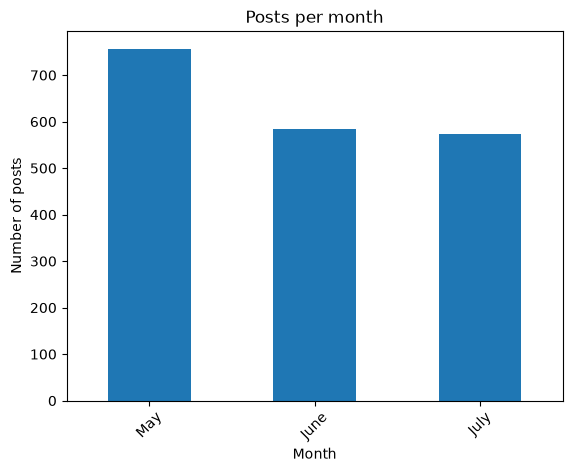

In [53]:
import calendar

counts = df['time'].dt.month.value_counts().sort_index()
counts.index = counts.index.map(lambda m: calendar.month_name[m])  # or month_abbr for "Jan", "Feb"

counts.plot(kind='bar', rot=45)
plt.xlabel('Month')
plt.ylabel('Number of posts')
plt.title('Posts per month')
plt.show()

# WordCloud

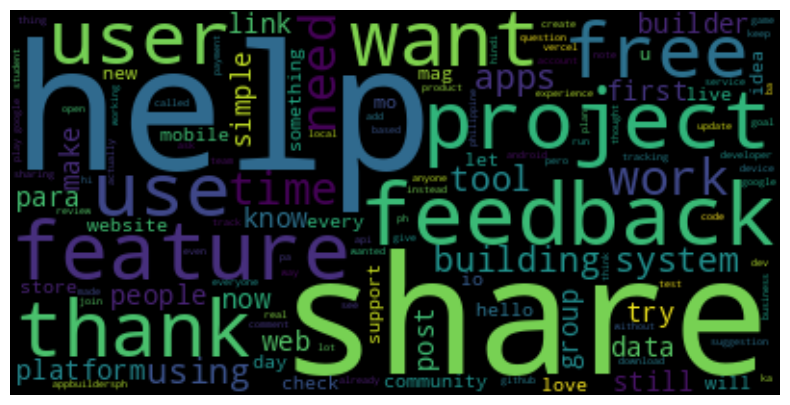

In [136]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS) | { 
    'na', 'ng', 'sa', 
    'ang', 'may', 'app', 
    'built', 'build', 'po', 
    'yung', 's', 'https',
    'mga', 'ai', 'ko', 'lang',
    'one', 'ako'
}
wc = WordCloud(stopwords=stopwords).generate(' '.join(df['text']).lower())
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

# Word Cloud (May Posts)

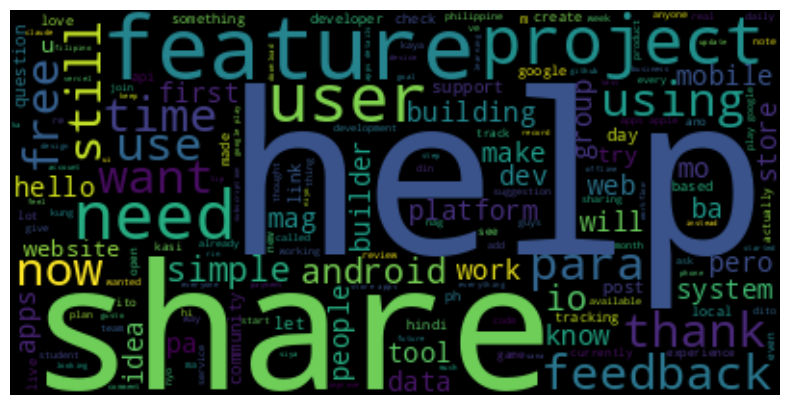

In [137]:
posts_may = df[(df['time'] >= '2026-05-01') & (df['time'] < '2026-06-01')]
wc = WordCloud(stopwords=stopwords).generate(' '.join(posts_may['text']).lower())
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

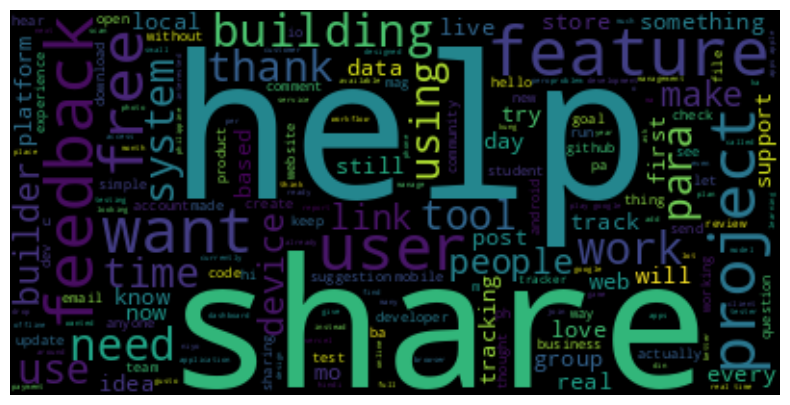

In [138]:
posts_june = df[(df['time'] >= '2026-06-01') & (df['time'] < '2026-07-01')]
wc = WordCloud(stopwords=stopwords).generate(' '.join(posts_june['text']).lower())
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

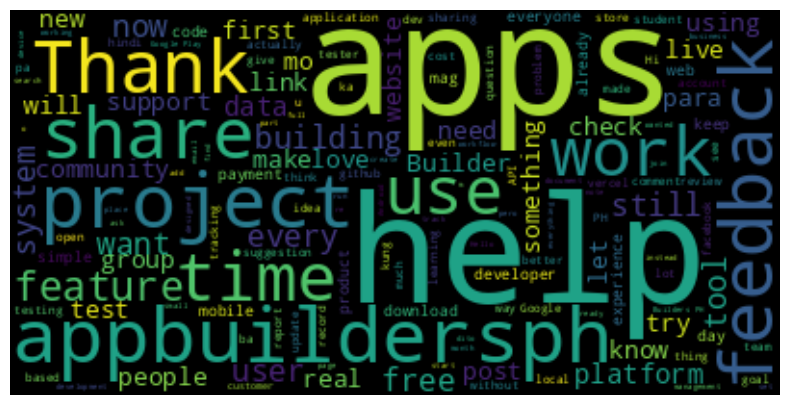

In [139]:
posts_july = df[(df['time'] >= '2026-07-01') & (df['time'] < '2026-08-01')]
wc = WordCloud(stopwords=stopwords).generate(' '.join(posts_july['text']))
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()